In [2]:
import os

# 1. DOWNLOADEN VAN DE MICROSOFT REPOSITORY
# We halen de originele code van Microsoft van het internet (GitHub) 
# en plaatsen deze in een mapje in dit project.
print(" Downloaden van de Microsoft Repository...")
!git clone https://github.com/microsoft/MedImaging-ModelDriftMonitoring.git

# Controleer of het mapje succesvol is aangemaakt
if os.path.exists("MedImaging-ModelDriftMonitoring"):
    print("Repository is succesvol binnengehaald!")
else:
    print(" Er is iets misgegaan met downloaden.")

 Downloaden van de Microsoft Repository...
fatal: destination path 'MedImaging-ModelDriftMonitoring' already exists and is not an empty directory.
Repository is succesvol binnengehaald!


In [3]:
# 2. GEREEDSCHAP INSTALLEREN
# Installeer de benodigde pakketten met de juiste versies. 
# PyTorch is voor de AI, Pandas voor tabellen, Plotly voor grafieken.
# (De specifieke versies voorkomen foutmeldingen zoals 'Autocast errors')
%pip install torch torchvision pandas scikit-image torchxrayvision plotly scipy tqdm torchprof environs param jupyter opencv-python-headless torchmetrics mlflow tensorboard pytorch-lightning==1.9.5 lightning-bolts==0.7.0 sklearn-pandas
%pip install azureml-core
%pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached kaleido-1.3.0-py3-none-any.whl.metadata (5.6 kB)
Using cached kaleido-1.3.0-py3-none-any.whl (55 kB)
  Attempting uninstall: kaleido
    Found existing installation: kaleido 0.2.1
    Uninstalling kaleido-0.2.1:
      Successfully uninstalled kaleido-0.2.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
%%writefile MedImaging-ModelDriftMonitoring/src/scripts/vae/train.py
# =====================================================================
# IMPORTS: Benodigde bibliotheken inladen
# =====================================================================
# Importeer os en sys voor interactie met mappen, bestanden en systeempaden
import os, sys
# Importeer argparse om instellingen via de terminal (command-line) te kunnen meegeven
import argparse
# Importeer PyTorch (torch) voor het bouwen en trainen van het AI-model
import torch
# Importeer pandas en numpy voor het werken met respectievelijk tabellen en wiskundige arrays
import pandas as pd, numpy as np
# Importeer skimage.io om afbeeldingen (röntgenfoto's) in te lezen
import skimage.io
# Importeer torchxrayvision, een gespecialiseerde bibliotheek voor medische röntgen-AI
import torchxrayvision as xrv
# Importeer gereedschappen van PyTorch om datasets te beheren en in kleine groepjes (batches) te verwerken
from torch.utils.data import Dataset, DataLoader
# Importeer tqdm voor een mooie laadbalk tijdens het trainen in de terminal
from tqdm import tqdm

# =====================================================================
# SYSTEEMPADEN: Zorg dat externe scripts gevonden worden
# =====================================================================
# Voeg de hoofdmap van het project toe aan het Python-pad, zodat we de Microsoft code kunnen vinden
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../..')))
# Importeer het specifieke Variational Autoencoder (VAE) model uit de model_drift map
from src.model_drift.models.vae import VAE

def main():
    # =====================================================================
    # CONFIGURATIE: Instellingen en argumenten parseren
    # =====================================================================
    # Maak een parser aan om argumenten (zoals mappen en parameters) uit de terminal te lezen
    parser = argparse.ArgumentParser()
    # Definieer de mappen en bestanden die we verwachten als input
    parser.add_argument('--images-dir', type=str) # Map waar de afbeeldingen staan
    parser.add_argument('--tsv-file', type=str)   # Bestand met de patiëntgegevens en datums
    parser.add_argument('--output-dir', type=str) # Map waar het getrainde model opgeslagen moet worden
    # Definieer de trainingsparameters (met standaardwaarden als er niets wordt opgegeven)
    parser.add_argument('--epochs', type=int, default=50)      # Aantal keer dat het model de hele dataset ziet
    parser.add_argument('--batch-size', type=int, default=4)   # Aantal foto's dat tegelijk wordt verwerkt
    # Sla de ingevoerde argumenten op in de variabele 'args'
    args, _ = parser.parse_known_args()

    # Bepaal of we een snelle videokaart (NVIDIA CUDA) hebben, anders vallen we terug op de processor (CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # =====================================================================
    # DATA PREPARATIE: Metadata inladen en koppelen aan bestanden
    # =====================================================================
    # Lees het metadata-bestand (TSV) in en behandel de ImageID kolom expliciet als tekst
    df_orig = pd.read_csv(args.tsv_file, sep='\t', low_memory=False, dtype={'ImageID': str})
    # Zet de 'StudyDate_DICOM' (de datum van de foto) om naar een echt Python-datumformaat
    df_orig['StudyDate_DICOM'] = pd.to_datetime(df_orig['StudyDate_DICOM'], format='%Y%m%d', errors='coerce')

    # Haal een lijst op van alle bestanden die daadwerkelijk in onze afbeeldingsmap staan (voorkomt foutmeldingen)
    try: bestanden = set(os.listdir(args.images_dir))
    except: bestanden = set()

    # FUNCTIE: Een hulpfunctie om het juiste, volledige bestandspad bij een foto (ImageID) te zoeken
    def get_pad(img_id):
        # Als er geen ID is, geef niks terug
        if pd.isna(img_id): return None
        # Verwijder eventuele extensies om een 'schone' basis-naam te krijgen
        base_id = str(img_id).replace('.png', '').replace('.jpg', '').strip()
        # Controleer welke variant (png, jpg, of exact de input) in de map bestaat
        for optie in [f"{base_id}.png", f"{base_id}.jpg", str(img_id).strip()]:
            if optie in bestanden: return os.path.join(args.images_dir, optie)
        return None # Bestand niet gevonden

    # Pas de hulpfunctie toe om voor elke rij het kloppende pad naar de harde schijf op te slaan
    df_orig['Echt_Pad'] = df_orig['ImageID'].apply(get_pad)
    # Verwijder alle rijen waarbij de datum, de ID of de foto zelf ontbreekt
    df = df_orig.dropna(subset=['StudyDate_DICOM', 'ImageID', 'Echt_Pad']).reset_index(drop=True)
    
    # Sorteer de hele dataset op chronologische volgorde (oudste foto's eerst)
    df = df.sort_values('StudyDate_DICOM').reset_index(drop=True)
    
    # Bepaal het afkappunt: de eerste 30% van de data is onze 'gezonde' referentie (baseline)
    split_idx = int(len(df) * 0.30)
    # Maak een nieuwe tabel met uitsluitend deze referentie-data om de VAE op te trainen
    df_ref = df.iloc[:split_idx].copy().reset_index(drop=True)

    # =====================================================================
    # PYTORCH DATASET: Hoe de foto's ingeladen en bewerkt worden
    # =====================================================================
    class VAEDataset(Dataset):
        def __init__(self, df):
            self.df = df
            # Gebruik de resizer van torchxrayvision om alle foto's te schalen naar 128x128 pixels
            self.resizer = xrv.datasets.XRayResizer(128) 
            
        # Vertel PyTorch hoeveel foto's er in totaal in deze dataset zitten
        def __len__(self): return len(self.df)
        
        # Dit is de functie die daadwerkelijk één foto ophaalt en klaarzet voor het AI-model
        def __getitem__(self, idx):
            try:
                # Open de foto vanaf de schijf, forceer zwart-wit (as_gray), en zet om naar kommagetallen
                img = skimage.io.imread(self.df.iloc[idx]['Echt_Pad'], as_gray=True).astype(np.float32)
                # Als de foto toch meerdere kleur-dimensies heeft, pak dan alleen het eerste kanaal
                if img.ndim != 2: img = img[:, :, 0]
            except: 
                # Als het inlezen mislukt (bijv. corrupt bestand), geef dan een lege, zwarte foto terug
                img = np.zeros((128, 128), dtype=np.float32)

            # NORMALISATIE: Zorg dat de helderheid van pixels altijd op dezelfde schaal valt
            if img.max() <= 1.0: img = xrv.datasets.normalize(img, 1.0)          # Float beelden (0 tot 1)
            elif img.max() <= 255.0: img = xrv.datasets.normalize(img, 255.0)    # 8-bit beelden (0 tot 255)
            else: img = xrv.datasets.normalize(img, 65535.0)                     # 16-bit beelden (0 tot 65535)
            
            # Voeg een extra dimensie toe (voor de kanalen), verklein het, en zet om naar een PyTorch Tensor
            return torch.from_numpy(self.resizer(img[np.newaxis, ...])).float()

    # =====================================================================
    # TRAINING LOOPS: Het AI-model daadwerkelijk trainen
    # =====================================================================
    # Maak de DataLoader aan: Deze hakt de data in kleine stukjes (batches) en husselt (shuffle) ze
    # We zorgen dat de batch_size nooit groter is dan het totaal aantal foto's in de baseline
    loader = DataLoader(VAEDataset(df_ref), batch_size=min(args.batch_size, max(1, len(df_ref))), shuffle=True)
    
    # Initialiseer het VAE AI-model (Variational Autoencoder)
    # Dit model leert de 'normale' kenmerken van de foto's samen te drukken (naar zsize 128) en weer te herstellen
    vae = VAE(image_dims=(1, 128, 128), zsize=128, kl_coeff=0.1, log_recon_images=0).to(device)
    
    # Kies de 'Adam' optimizer; dit is de wiskundige motor die het model verbetert (met leersnelheid 1e-4)
    optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

    # Zet het model officieel in de 'train-modus' (nodig voor bepaalde PyTorch lagen zoals Dropout/BatchNorm)
    vae.train()
    
    # Loop over het vooraf ingestelde aantal rondes (epochs)
    for epoch in range(args.epochs):
        loss_sum = 0 # Houd bij hoe groot de 'fout' van het model is in deze ronde
        
        # Loop over alle groepjes foto's (batches) in de dataset met een mooie laadbalk (tqdm)
        for batch in tqdm(loader, desc=f"Epoch {epoch+1}/{args.epochs}"):
            optimizer.zero_grad() # Maak de berekeningen van de vorige stap leeg
            
            # Stuur de foto's naar de videokaart/processor en doe een voorspelling (forward pass)
            loss, _, _ = vae.step(batch.to(device))
            
            # Bereken hoever het model ernaast zat en stuur die fout terug (backward pass)
            loss.backward()
            
            # Pas de instellingen (gewichten) van het model een klein beetje aan om beter te worden
            optimizer.step()
            
            # Tel de fout op bij de totale fout van deze ronde
            loss_sum += loss.item()
            
        # Print na elke ronde de gemiddelde fout, zodat we kunnen zien of het model daadwerkelijk leert (de fout moet dalen)
        print(f"Epoch {epoch+1} Loss: {loss_sum/max(1, len(loader)):.4f}")

    # =====================================================================
    # OPSLAAN: Het getrainde model wegschrijven voor later gebruik
    # =====================================================================
    # Zorg dat de doelmap bestaat
    os.makedirs(args.output_dir, exist_ok=True)
    # Sla de 'hersens' (state_dict) van de AI op in een .ckpt (checkpoint) bestand
    torch.save({'state_dict': vae.state_dict()}, os.path.join(args.output_dir, 'vae_weights.ckpt'))

# Zorg ervoor dat het script alleen draait als het direct wordt aangeroepen (niet als het ergens anders wordt geïmporteerd)
if __name__ == '__main__': main()

Overwriting MedImaging-ModelDriftMonitoring/src/scripts/vae/train.py


In [6]:
%%writefile MedImaging-ModelDriftMonitoring/src/scripts/vae/score.py
# =====================================================================
# IMPORTS: Benodigde bibliotheken inladen
# =====================================================================
# Importeer os, argparse, torch en sys voor systeempaden, terminal-argumenten en AI-functies
import os, argparse, torch, sys
# Importeer pandas (tabellen), numpy (wiskunde) en skimage.io (röntgenfoto's openen)
import pandas as pd, numpy as np, skimage.io
# Importeer torchxrayvision voor medische beeldverwerking
import torchxrayvision as xrv
# Importeer PyTorch gereedschappen voor het groeperen en inladen van de data
from torch.utils.data import Dataset, DataLoader
# Importeer tqdm voor de laadbalk tijdens het genereren van de scores
from tqdm import tqdm

# =====================================================================
# SYSTEEMPADEN: Zorg dat de code het VAE-model kan vinden
# =====================================================================
# Voeg de hoofdmap toe aan het systeem zodat Python de map 'src' herkent
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../..')))
# Importeer de structuur van het Variational Autoencoder (VAE) model
from src.model_drift.models.vae import VAE

def main():
    # =====================================================================
    # CONFIGURATIE: Instellingen en terminal-argumenten
    # =====================================================================
    parser = argparse.ArgumentParser()
    parser.add_argument('--images-dir', type=str) # Map met de foto's
    parser.add_argument('--tsv-file', type=str)   # Tabel met patiëntgegevens
    parser.add_argument('--model-path', type=str) # Het pad naar het model dat we in 'train.py' hebben opgeslagen
    parser.add_argument('--output-dir', type=str) # Waar de uiteindelijke scores (CSV) opgeslagen moeten worden
    parser.add_argument('--batch-size', type=int, default=4) # Aantal foto's per keer
    args, _ = parser.parse_known_args()

    # Gebruik de videokaart als die beschikbaar is, anders de processor
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Lees de metadata in en behandel het ImageID veilig als tekst
    df = pd.read_csv(args.tsv_file, sep='\t', low_memory=False, dtype={'ImageID': str})
    
    # Kijk welke bestanden we fysiek op de schijf hebben staan
    try: bestanden = set(os.listdir(args.images_dir))
    except: bestanden = set()

    # =====================================================================
    # DATA PREPARATIE: Bestanden koppelen
    # =====================================================================
    # FUNCTIE: Zoek het juiste bestand (.png of .jpg) bij het ImageID
    def get_pad(img_id):
        if pd.isna(img_id): return None
        base_id = str(img_id).replace('.png', '').replace('.jpg', '').strip()
        for optie in [f"{base_id}.png", f"{base_id}.jpg", str(img_id).strip()]:
            if optie in bestanden: return os.path.join(args.images_dir, optie)
        return None
        
    # Koppel het bestandspad en gooi rijen zonder kloppend bestand weg
    df['Echt_Pad'] = df['ImageID'].apply(get_pad)
    df = df.dropna(subset=['ImageID', 'Echt_Pad']).reset_index(drop=True)

    # =====================================================================
    # PYTORCH DATASET: Data inladen voor het scoren
    # =====================================================================
    class VAEScoreData(Dataset):
        def __init__(self, df):
            self.df = df
            self.resizer = xrv.datasets.XRayResizer(128) # Schaal alles naar 128x128
            
        def __len__(self): return len(self.df)
        
        def __getitem__(self, idx):
            # Open de foto (zwart-wit) en zet om naar getallen
            try:
                img = skimage.io.imread(self.df.iloc[idx]['Echt_Pad'], as_gray=True).astype(np.float32)
                if img.ndim != 2: img = img[:, :, 0]
            except: img = np.zeros((128, 128), dtype=np.float32)

            # Normaliseer de helderheid zodat het AI-model er goed mee kan rekenen
            if img.max() <= 1.0: img = xrv.datasets.normalize(img, 1.0)
            elif img.max() <= 255.0: img = xrv.datasets.normalize(img, 255.0)
            else: img = xrv.datasets.normalize(img, 65535.0)
            
            # LET OP: Bij het trainen stuurden we alleen de foto terug. Nu sturen we óók het ImageID
            # mee terug, zodat we straks weten welke scores bij welke patiënt/foto horen.
            return torch.from_numpy(self.resizer(img[np.newaxis, ...])).float(), self.df.iloc[idx]['ImageID']

    # Maak de DataLoader aan (shuffle=False, want we willen de data netjes op volgorde scoren)
    loader = DataLoader(VAEScoreData(df), batch_size=args.batch_size, shuffle=False, drop_last=True)
    
    # =====================================================================
    # MODEL INLADEN: Haal het opgeslagen brein op
    # =====================================================================
    # Maak een lege versie van ons model aan
    vae = VAE(image_dims=(1, 128, 128), zsize=128, kl_coeff=0.1, log_recon_images=0).to(device)
    # Laad het 'brein' (de gewichten) dat we zojuist in het vorige script getraind hebben in dit model
    vae.load_state_dict(torch.load(args.model_path, map_location=device)['state_dict'])
    # Zet het model in 'evaluatie-modus' (eval). Dit bevriest lagen zoals Dropout, zodat het niet meer per ongeluk leert of resultaten beïnvloedt.
    vae.eval()

    # =====================================================================
    # EXTRACTIE: Beelden scoren en eigenschappen opslaan
    # =====================================================================
    results = []
    
    # torch.no_grad() vertelt de AI dat we niks gaan trainen. Dit bespaart heel veel rekenkracht en geheugen.
    with torch.no_grad():
        # Loop door de beelden heen met een laadbalk
        for batch_img, batch_ids in tqdm(loader, desc="VAE Extractie"):
            # Stuur de batch foto's door het model
            out = vae(batch_img.to(device))
            
            # Het model spuugt meerdere dingen uit (reconstructie, foutmarge, etc.).
            # Wij willen 'mu': dit is de samengevatte 'essentie' (128 getallen) van de foto.
            mu = (out[2] if len(out)==4 else out[1]).cpu().numpy()
            
            # Koppel de berekende 128 eigenschappen aan de juiste afbeeldings-ID
            for img_id, latents in zip(batch_ids, mu):
                row = {'ImageID': img_id.item() if hasattr(img_id, 'item') else img_id}
                # Sla elk van de 128 getallen op in een eigen kolom (mu.000 t/m mu.127)
                for i in range(128): row[f'mu.{i:03d}'] = latents[i]
                results.append(row)
                
    # =====================================================================
    # OPSLAAN: Tabel genereren
    # =====================================================================
    # Zorg dat de output-map bestaat
    os.makedirs(args.output_dir, exist_ok=True)
    # Maak een pandas DataFrame van de lijst met resultaten en sla dit op als CSV
    pd.DataFrame(results).to_csv(os.path.join(args.output_dir, 'vae_scores.csv'), index=False)

# Zorg ervoor dat het script alleen draait als het direct wordt aangeroepen
if __name__ == '__main__': main()

Overwriting MedImaging-ModelDriftMonitoring/src/scripts/finetune/score.py


In [7]:
%%writefile MedImaging-ModelDriftMonitoring/src/scripts/drift/generate_drift_csv.py
# =====================================================================
# IMPORTS: Benodigde bibliotheken inladen
# =====================================================================
# Importeer os, argparse en sys voor mappenstructuur en terminal-commando's
import os, argparse, sys
# Importeer pandas (tabellen) en numpy (wiskundige bewerkingen)
import pandas as pd, numpy as np
# Importeer statistische testen: KS-test voor numerieke reeksen, Chi2 voor categorieën
from scipy.stats import ks_2samp, chi2_contingency
# Importeer roc_auc_score om te meten hoe goed de AI het écht deed (Ground Truth)
from sklearn.metrics import roc_auc_score

# =====================================================================
# SYSTEEMPADEN: Zorg dat we interne tools kunnen vinden
# =====================================================================
# Voeg de hoofdmap toe aan het Python-pad
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../..')))
# Importeer FigureHelper, een Microsoft-tooltje uit de repo om makkelijk grafieken te tekenen
from src.model_drift.figure_helper import FigureHelper

def main():
    # =====================================================================
    # CONFIGURATIE: Instellingen en argumenten parseren
    # =====================================================================
    parser = argparse.ArgumentParser()
    parser.add_argument('--tsv-file', type=str)     # Originele metadata (leeftijd, geslacht, etc.)
    parser.add_argument('--vae-scores', type=str)   # De geëxtraheerde 128 eigenschappen van de VAE
    parser.add_argument('--clf-scores', type=str)   # De AI-voorspellingen (kans op Pneumonie)
    parser.add_argument('--weights-file', type=str) # Hoe zwaar weegt elke variabele mee in het alarm?
    parser.add_argument('--output-dir', type=str)   # Waar we de CSV's en HTML-grafieken opslaan
    args, _ = parser.parse_known_args()

    # =====================================================================
    # 1. DATA INLADEN EN KOPPELEN
    # =====================================================================
    # Lees de drie losse databronnen in
    df_meta = pd.read_csv(args.tsv_file, sep='\t', low_memory=False)
    df_vae = pd.read_csv(args.vae_scores, dtype={'ImageID': str})
    df_clf = pd.read_csv(args.clf_scores, dtype={'ImageID': str})

    # Verwijder bestandsextensies zodat we overal een schone ImageID hebben om op te matchen
    for d in [df_meta, df_vae, df_clf]:
        d['ImageID'] = d['ImageID'].astype(str).str.replace('.png', '', regex=False).str.replace('.jpg', '', regex=False)

    # Voeg alles samen (inner join) tot één grote 'Master' tabel op basis van ImageID
    df = pd.merge(df_meta, df_vae, on='ImageID', how='inner')
    df = pd.merge(df, df_clf, on='ImageID', how='inner')
    
    # Zet de datum om naar een kloppend formaat en sorteer alles chronologisch
    df['StudyDate_DICOM'] = pd.to_datetime(df['StudyDate_DICOM'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['StudyDate_DICOM']).sort_values('StudyDate_DICOM').reset_index(drop=True)

    # Definieer welke metadata we in de gaten willen houden op drift
    # Continue waarden (getallen, zoals leeftijd en foto-dimensies)
    meta_cont_kandidaat = ['age', 'Columns_DICOM', 'Rows_DICOM']
    # Categorische waarden (tekst of groepen, zoals geslacht of scanner-merk)
    meta_cat_kandidaat = ['PatientSex', 'ViewPosition', 'Manufacturer', 'Modality']
    
    # Controleer of deze kolommen daadwerkelijk in onze dataset bestaan
    meta_cont = [c for c in meta_cont_kandidaat if c in df.columns]
    meta_cat = [c for c in meta_cat_kandidaat if c in df.columns]

    # Geef een waarschuwing als we niet kunnen controleren of patiënten écht ziek waren
    if 'Labels' not in df.columns:
        print(" WAARSCHUWING: Kolom 'Labels' niet gevonden! AUROC kan niet berekend worden.")
    
    # =====================================================================
    # DATA SPLITSEN: Referentie (Gezond) versus Productie (Live)
    # =====================================================================
    # Splits de tijdlijn: De eerste 30% is onze 'Gezonde Referentie' (Baseline)
    split_idx = int(len(df) * 0.30)
    df_ref = df.iloc[:split_idx].copy()
    # De laatste 70% simuleren we als de live 'Productie' tijdlijn waar drift kan optreden
    df_prod = df.iloc[split_idx:].copy() 
    
    # Laad het gewichten-bestand in (indien beschikbaar) om te bepalen welke features belangrijk zijn
    weights_dict = {}
    if os.path.exists(args.weights_file):
        df_weights = pd.read_csv(args.weights_file)
        # Filter op afstands-statistieken (distance)
        if 'Unnamed: 2' in df_weights.columns:
            df_weights = df_weights[df_weights['Unnamed: 2'] == 'distance']
            # Maak een dictionary aan: { 'feature_naam': gewicht }
            weights_dict = dict(zip(df_weights['Unnamed: 0'], df_weights['abs(corr)']))

    # Zet alle numerieke kolommen op een rij die we gaan monitoren (Voorspelling + Leeftijd/Dimensies + VAE mu's)
    kolommen = ['prob_Pneumonia'] + meta_cont + [f'mu.{i:03d}' for i in range(128)]
    beschikbare_features = [c for c in kolommen if c in df.columns]

    print(f" Analyse opstarten... Baseline N={len(df_ref)}, Productie N={len(df_prod)}")
    
    # =====================================================================
    # 2. Referentie set BEREKENEN VOOR HET ALARM (MMC)
    # =====================================================================
    # Doel: Wat is de 'natuurlijke' schommeling van de data als er géén drift is?
    baseline = {}
    FIXED_SAMPLE_SIZE = min(50, len(df_ref) // 3) 
    bootstraps = {c: [] for c in beschikbare_features}
    
    # Trek 50 keer een willekeurige steekproef uit de referentiedata (Monte Carlo methode)
    for _ in range(50):
        samp = df_ref.sample(n=FIXED_SAMPLE_SIZE, replace=True)
        for c in beschikbare_features:
            d_ref, d_samp = df_ref[c].dropna(), samp[c].dropna()
            # Als we genoeg patiënten hebben, bereken dan de afstand (KS-test) tussen de steekproef en het geheel
            if len(d_ref) > 10 and len(d_samp) > 10:
                stat, _ = ks_2samp(d_ref, d_samp)
                bootstraps[c].append(stat)
                
    # Bereken nu de gemiddelde schommeling (mean) en de spreiding (std) van deze 'gezonde' afstanden
    for c, dists in bootstraps.items():
        if dists: 
            # Forceer een minimale spreiding (0.02) om te voorkomen dat we later delen door nul
            baseline[c] = {'mean': np.mean(dists), 'std': max(np.std(dists), 0.02)}

    # =====================================================================
    # 3. DRIFT BEREKENEN PER MAAND OVER DE TIJDLIJN
    # =====================================================================
    results_mmc, results_auroc = [], []
    tracking_ks, tracking_chi2 = [], []
    
    # Zet het startpunt (Datum 0) netjes op 0 in de grafiek
    anchor_date = df_ref['StudyDate_DICOM'].max()
    if not pd.isna(anchor_date):
        results_mmc.append({'Datum': anchor_date, 'MMC': 0.0}) 
        
        # Bereken ook de begin-score (AUROC) voor de AI op de referentie-data
        if 'Labels' in df_ref.columns and 'prob_Pneumonia' in df_ref.columns:
            y_true_ref = df_ref['Labels'].apply(lambda x: 1 if str(x).strip() == '1' or 'pneumonia' in str(x).lower() else 0)
            if len(y_true_ref.unique()) > 1:
                ref_auc = roc_auc_score(y_true_ref, df_ref['prob_Pneumonia'])
                results_auroc.append({'Datum': anchor_date, 'AUROC_Score': ref_auc})

    # Groepeer de productie-data op de frequentie van Maanden (M)
    maanden = [g for n, g in df_prod.groupby(pd.Grouper(key='StudyDate_DICOM', freq='M'))]
    
    # Loop over elke productie-maand heen
    for i in range(len(maanden)):
        # ROLLING WINDOW: Plak de data van max 3 maanden aan elkaar om ruis en kleine groepen patiënten op te vangen
        if i == 0: win_df = maanden[i]
        elif i == 1: win_df = pd.concat([maanden[i-1], maanden[i]])
        else: win_df = pd.concat([maanden[i-2], maanden[i-1], maanden[i]])
            
        datum = maanden[i]['StudyDate_DICOM'].max()
        # Sla de maand over als we minder dan 30 patiënten hebben (statistisch niet verantwoord)
        if pd.isna(datum) or len(win_df) < 30:
            continue

        # --- A) MMC SCORE BEREKENEN (Multi-Modal Concordance Alarm) ---
        teller, noemer = 0.0, 0.0
        for c in baseline.keys():
            if c in win_df.columns:
                stats = []
                d_win = win_df[c].dropna()
                # Trek 10 steekproeven uit de huidige maand voor een robuust gemiddelde
                for _ in range(10):
                    if len(d_win) >= FIXED_SAMPLE_SIZE:
                        samp = d_win.sample(n=FIXED_SAMPLE_SIZE, replace=True)
                        s, _ = ks_2samp(df_ref[c].dropna(), samp) # Vergelijk huidige maand met de baseline
                        stats.append(s)
                
                if stats:
                    gemiddelde_stat = np.mean(stats)
                    # Z-Score: (Huidige afwijking - Gezonde afwijking) / Gezonde spreiding
                    z_score = (gemiddelde_stat - baseline[c]['mean']) / baseline[c]['std']
                    # Kap extreme waarden af tussen -3 en 3 om te voorkomen dat 1 gekke feature alles dicteert
                    z_score = np.clip(z_score, -3.0, 3.0) 
                    
                    # Vermenigvuldig met het 'belangrijkheids-gewicht' van de feature
                    gew = weights_dict.get(c, 0.1)
                    teller += gew * z_score
                    noemer += gew
                    
        # Bereken eindscore. Let op het min-teken: een hoge afwijking trekt de grafiek naar beneden 
        mmc_score = -(teller/noemer) if noemer > 0 else 0
        results_mmc.append({'Datum': datum, 'MMC': mmc_score})

        # --- B) KLINISCHE PRESTATIES BEREKENEN (AUROC) ---
        if 'Labels' in win_df.columns and 'prob_Pneumonia' in win_df.columns:
            # Vertaal de labels naar een 1 (ziek) of 0 (gezond)
            y_true = win_df['Labels'].apply(lambda x: 1 if str(x).strip() == '1' or 'pneumonia' in str(x).lower() else 0)
            y_pred = win_df['prob_Pneumonia'].astype(float)
            
            # Je kan alleen een ROC-curve tekenen als er minimaal één zieke en één gezonde patiënt is
            if len(y_true.unique()) > 1:
                auc = roc_auc_score(y_true, y_pred)
                results_auroc.append({'Datum': datum, 'AUROC_Score': auc})

        # --- C) METADATA DRIFT (Demografie etc.) ---
        # 1. Continue waarden (bijv. leeftijd via KS-test)
        maand_ks = {'Datum': datum}
        for c in meta_cont:
            d_ref, d_win = df_ref[c].dropna(), win_df[c].dropna()
            if len(d_ref) > 10 and len(d_win) > 10:
                stat, pval = ks_2samp(d_ref, d_win)
                maand_ks[f'{c}_KS_Score'] = stat
                maand_ks[f'{c}_P_Value'] = pval
        tracking_ks.append(maand_ks)

        # 2. Categorische waarden (bijv. geslacht via Chi-Kwadraat test)
        maand_chi2 = {'Datum': datum}
        for c in meta_cat:
            ref_counts = df_ref[c].value_counts()
            win_counts = win_df[c].value_counts()
            all_cats = list(set(ref_counts.index) | set(win_counts.index))
            
            ref_freq = [ref_counts.get(cat, 0) for cat in all_cats]
            win_freq = [win_counts.get(cat, 0) for cat in all_cats]
            
            if sum(ref_freq) > 0 and sum(win_freq) > 0:
                try:
                    chi2_stat, pval, _, _ = chi2_contingency([ref_freq, win_freq])
                    maand_chi2[f'{c}_Chi2_Score'] = chi2_stat
                    maand_chi2[f'{c}_P_Value'] = pval
                except ValueError: pass # Bij rekenfouten door lege tabellen vangen we dit stilletjes op
        tracking_chi2.append(maand_chi2)

    # =====================================================================
    # 4. OPSLAAN & VISUALISEREN (Dashboards maken)
    # =====================================================================
    os.makedirs(args.output_dir, exist_ok=True)
    
    # -- DASHBOARD 1: Het MMC Alarm --
    if len(results_mmc) > 1:
        df_mmc = pd.DataFrame(results_mmc).set_index('Datum')
        # Exponential Moving Average: Strijk de harde pieken glad voor een betere visuele trend
        df_mmc['MMC_Smoothed'] = df_mmc['MMC'].ewm(span=4, adjust=False).mean()
        df_mmc.to_csv(os.path.join(args.output_dir, 'mmc_results_smoothed.csv'))
        
        # Gebruik de Microsoft FigureHelper om het dashboard te tekenen
        h_mmc = FigureHelper(x=df_mmc.index)
        h_mmc.add_trace(y=df_mmc['MMC_Smoothed'], name='Stabiele MMC Trend', line=dict(color='blue', width=3))
        fig_mmc = h_mmc.make_fig()
        
        fig_mmc.update_layout(title_text="Model Drift: Multi-Modal Concordance (0 = Stabiel, Negatief = Drift)", yaxis=dict(range=[-4.0, 2.0]))
        fig_mmc.add_hline(y=0, line_dash="dash", line_color="green", opacity=0.8) # Teken de gezonde nullijn
        fig_mmc.write_html(os.path.join(args.output_dir, 'dashboard_1_mmc_smoothed.html'))

    # -- DASHBOARD 2: De Klinische Prestaties (AUROC) --
    if len(results_auroc) > 1:
        df_auc = pd.DataFrame(results_auroc).set_index('Datum')
        df_auc['AUROC_Smoothed'] = df_auc['AUROC_Score'].ewm(span=4, adjust=False).mean()
        df_auc.to_csv(os.path.join(args.output_dir, 'auroc_results.csv'))
        
        h_auc = FigureHelper(x=df_auc.index)
        h_auc.add_trace(y=df_auc['AUROC_Smoothed'], name='AUROC Trend (Smoothed)', line=dict(color='darkred', width=3))
        fig_auc = h_auc.make_fig()
        
        fig_auc.update_layout(title_text="Model Performance: AUROC (Ground Truth)", yaxis=dict(range=[0.2, 1.05]))
        fig_auc.add_hline(y=0.5, line_dash="dash", line_color="black", opacity=0.5) # Teken de 50% lijn (gokken)
        fig_auc.write_html(os.path.join(args.output_dir, 'dashboard_2_auroc.html'))

    # -- METADATA OPSLAAN --
    meta_dir = os.path.join(args.output_dir, 'metadata_stats')
    os.makedirs(meta_dir, exist_ok=True)
    
    # Exporteer de pure statistische tests zodat we die in een ander script in detail kunnen bekijken
    if tracking_ks: pd.DataFrame(tracking_ks).set_index('Datum').to_csv(os.path.join(meta_dir, 'metadata_continuous_ks.csv'))
    if tracking_chi2: pd.DataFrame(tracking_chi2).set_index('Datum').to_csv(os.path.join(meta_dir, 'metadata_categorical_chi2.csv'))

    print(f" Dashboards klaar!  Metadata drift details zijn opgeslagen in: {meta_dir}")

# Zorg dat het direct gestart kan worden als script
if __name__ == '__main__': main()

Overwriting MedImaging-ModelDriftMonitoring/src/scripts/drift/generate_drift_csv.py


In [8]:
import sys
import os
import torch

# 1. Zorg dat het notebook de Microsoft broncode map kan vinden
repo_path = os.path.abspath("./MedImaging-ModelDriftMonitoring")
if repo_path not in sys.path:
    sys.path.append(repo_path)

# 2. Importeer de hoofdfuncties uit de scripts die we in de vorige cellen hebben geschreven
from src.scripts.vae.train import main as train_vae
from src.scripts.vae.score import main as score_vae
from src.scripts.finetune.score import main as score_clf
from src.scripts.drift.generate_drift_csv import main as generate_drift

print(f" Schone start. PyTorch {torch.__version__} is actief.")
print("---  Starten van de Modulaire Pipeline ---")

# Het bestand met de metadata van de foto's
ECHTE_TSV = "pneumo_dataset_ITI_rev.tsv"

print("\n[1/4] VAE Baseline Trainen...")
sys.argv = ["train.py", "--images-dir", "./test_beelden", "--tsv-file", ECHTE_TSV, "--output-dir", "./pipeline_data", "--epochs", "50", "--batch-size", "4"]
train_vae()

print("\n[2/4] Visuele Scores Extraheren (VAE)...")
sys.argv = ["score.py", "--images-dir", "./test_beelden", "--tsv-file", ECHTE_TSV, "--model-path", "./pipeline_data/vae_weights.ckpt", "--output-dir", "./pipeline_data", "--batch-size", "4"]
score_vae()

print("\n[3/4] Klinische Scores Extraheren (DenseNet)...")
sys.argv = ["score.py", "--images-dir", "./test_beelden", "--tsv-file", ECHTE_TSV, "--output-dir", "./pipeline_data", "--batch-size", "4"]
score_clf()

print("\n[4/4] Model Drift Berekenen & Dashboard Genereren...")
sys.argv = ["generate-drift-csv.py", "--tsv-file", ECHTE_TSV, "--vae-scores", "./pipeline_data/vae_scores.csv", "--clf-scores", "./pipeline_data/clf_scores.csv", "--weights-file", "MedImaging-ModelDriftMonitoring/models/weights/metric_weights.csv", "--output-dir", "./pipeline_data"]
generate_drift()

print("\n Klaar! Bekijk de ./pipeline_data map voor je interactieve dashboard!")

 Schone start. PyTorch 2.12.0+cu130 is actief.
---  Starten van de Modulaire Pipeline ---

[1/4] VAE Baseline Trainen...


Epoch 1/50: 100%|██████████| 404/404 [00:23<00:00, 16.85it/s]


Epoch 1 Loss: 409825.3558


Epoch 2/50: 100%|██████████| 404/404 [00:23<00:00, 16.91it/s]


Epoch 2 Loss: 409615.6813


...

Epoch 50 Loss: 409516.9617

[2/4] Visuele Scores Extraheren (VAE)...


VAE Extractie: 100%|██████████| 1347/1347 [00:37<00:00, 35.73it/s]



[3/4] Klinische Scores Extraheren (DenseNet)...


DenseNet Extractie: 100%|██████████| 1347/1347 [04:12<00:00,  5.33it/s]



[4/4] Model Drift Berekenen & Dashboard Genereren...
 Analyse opstarten... Baseline N=1616, Productie N=3772
 Dashboards klaar!  Metadata drift details zijn opgeslagen in: ./pipeline_data/metadata_stats

 Klaar! Bekijk de ./pipeline_data map voor je interactieve dashboard!


In [81]:
# Importeer os en sys voor interactie met mappen en systeempaden
import os, sys, shutil
# Importeer pandas voor het werken met tabellen (dataframes)
import pandas as pd
# Importeer numpy voor wiskundige berekeningen
import numpy as np
# Importeer PIL (Pillow) om afbeeldingen (röntgenfoto's) te openen en bewerken
from PIL import Image
# Importeer roc_auc_score om de klinische prestaties (AUROC) te berekenen
from sklearn.metrics import roc_auc_score
# Importeer statistische testen (KS-test voor numeriek, Chi2 voor categorieën)
from scipy.stats import ks_2samp, chi2_contingency 
# Importeer Plotly voor het maken van de interactieve grafieken
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Importeer display tools voor weergave in Jupyter Notebooks
from IPython.display import HTML, display
# Onderdruk onnodige waarschuwingen in de output
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# CONFIGURATIE: Instellingen voor de sabotage en analyse
# =====================================================================
CONFIG = {
    "fysieke_visuele_drift": False ,         # Zet de beeldsabotage (ruis/helderheid) AAN
    "helderheid_factor": 1 ,              # Maak de beelden x lichter tijdens sabotage
    "ruis_factor": 0,                     # Voeg een laag fotonenruis toe
    "simuleer_conventionele_drift": True , # Zet demografische sabotage (patiëntleeftijd) UIT
    "drift_start_percentage": 0.60,        # Start de sabotage na 60% van de tijdlijn
    
    "filter_start_date": "2015-08-01",     # Startdatum van de analyse
    "filter_end_date": "2017-06-01",       # Einddatum van de analyse
    "analyse_interval": "W",               # Bereken drift per Week (W)
    "rolling_window_periodes": 1,          # Kijk voor driftberekening 1 week terug
    "smoothing_factor": 7,                 # Gladstrijken van de hoofdlijnen
    "smoothing_factor_zwaar": 9,           # Extra gladstrijken voor de ruisgevoelige lijnen
    
    # ACCURATERE BOOTSTRAPS (Monte Carlo sampling voor statistische robuustheid)
    "bootstrap_baseline_iteraties": 200,   # Maak 200 steekproeven om de gezonde norm te bepalen
    "bootstrap_live_iteraties": 50         # Maak 50 steekproeven per week voor een stabiele score
}

# Definieer de mappen waar de beelden staan en opgeslagen moeten worden
BRON_MAP = "./test_beelden"
EXP_DIR = os.path.abspath("./pipeline_data/master_experiment")
IMG_DIR = f"{EXP_DIR}/images"

print("[1/6] Mappen maken en data inladen...")
# Maak de doelmap voor beelden aan als deze nog niet bestaat
os.makedirs(IMG_DIR, exist_ok=True)
# Lees het TSV-bestand (metadata) in met pandas
df_meta = pd.read_csv("pneumo_dataset_ITI_rev.tsv", sep='\t', low_memory=False)
# Zet de DICOM-datum kolom om naar een echt datum-formaat dat Python begrijpt
df_meta['StudyDate_DICOM'] = pd.to_datetime(df_meta['StudyDate_DICOM'], format='%Y%m%d', errors='coerce')
# Verwijder rijen zonder datum, sorteer alles op tijd, en reset de index
df_meta = df_meta.dropna(subset=['StudyDate_DICOM']).sort_values('StudyDate_DICOM').reset_index(drop=True)

# Filter de dataset zodat we alleen data tussen de geconfigureerde start- en einddatum hebben
df_meta = df_meta[
    (df_meta['StudyDate_DICOM'] >= pd.to_datetime(CONFIG["filter_start_date"])) & 
    (df_meta['StudyDate_DICOM'] <= pd.to_datetime(CONFIG["filter_end_date"]))
].reset_index(drop=True)

# Bereken op welk rij-nummer de 60% grens (drift start) ligt
split_idx = int(len(df_meta) * CONFIG["drift_start_percentage"])
# Zoek de daadwerkelijke datum op die bij dit omslagpunt hoort
drift_start_date = df_meta.iloc[split_idx]['StudyDate_DICOM'].strftime('%Y-%m-%d')

print(f"[2/6] Fysieke drift toepassen vanaf {drift_start_date}...")
# Loop door elke rij (afbeelding) in de gefilterde metadata
for i, row in df_meta.iterrows():
    # Haal de afbeeldingsnaam op en zorg dat deze eindigt op .png
    img_name = str(row['ImageID']).replace('.png', '').replace('.jpg', '') + '.png'
    # Definieer het bronpad en het doelpad voor deze specifieke afbeelding
    src, dst = os.path.join(BRON_MAP, img_name), os.path.join(IMG_DIR, img_name)
    
    # Controleer of de afbeelding daadwerkelijk bestaat op de harde schijf
    if os.path.exists(src):
        # Als we voorbij het 60% omslagpunt zijn EN fysieke drift staat aan: Saboteer!
        if i >= split_idx and CONFIG["fysieke_visuele_drift"]:
            img = Image.open(src) # Open de originele afbeelding
            orig_array = np.array(img) # Zet de afbeelding om in een matrix van getallen
            orig_dtype = orig_array.dtype # Sla het originele data-type (bijv. 8-bit of 16-bit) op
            
            # Controleer of het een 16-bit (hoge kwaliteit) medisch beeld is
            is_16bit = (orig_array.max() > 255) or (orig_dtype in [np.uint16, np.int16, np.int32])
            max_val = 65535.0 if is_16bit else 255.0 # Bepaal de maximale pixelwaarde
            
            # Zet om naar kommagetallen (float) zodat we ermee kunnen rekenen
            np_img = orig_array.astype(np.float32) 
            # Maak het beeld lichter/donkerder door te vermenigvuldigen met de factor (bijv 1.4)
            np_img = np_img * CONFIG["helderheid_factor"]
            
            # Als er ruis is ingesteld in de configuratie, voeg dit dan toe
            if CONFIG.get("ruis_factor", 0) > 0:
                schaal_factor = max_val / 255.0 # Schaal de ruis voor 16-bit beelden
                geschaalde_ruis = CONFIG["ruis_factor"] * schaal_factor
                
                h, w = np_img.shape[:2] # Haal de hoogte en breedte van het origineel op
                ai_res = 224 # Definieer de lage resolutie van de AI (224x224 pixels)
                
                # Genereer grove 'basis' ruis op 224x224 resolutie (voorkomt AI weg-filtering)
                basis_ruis_laag = np.random.normal(0, geschaalde_ruis * 0.3, (ai_res, ai_res)).astype(np.float32)
                # Genereer anatomische afhankelijke ruis (Quantum Mottle)
                anatomie_ruis_laag = np.random.normal(0, geschaalde_ruis * 0.7, (ai_res, ai_res)).astype(np.float32)
                
                # Blaas de lage resolutie ruis op naar de grootte van het originele beeld
                basis_ruis_hoog = np.array(Image.fromarray(basis_ruis_laag, mode='F').resize((w, h), Image.BILINEAR))
                anatomie_ruis_hoog = np.array(Image.fromarray(anatomie_ruis_laag, mode='F').resize((w, h), Image.BILINEAR))
                
                # Als het een RGB (kleur/3-kanaals) beeld is, kopieer de ruis dan over de 3 kleurkanalen
                if len(np_img.shape) == 3: 
                    basis_ruis_hoog = np.stack([basis_ruis_hoog]*3, axis=-1)
                    anatomie_ruis_hoog = np.stack([anatomie_ruis_hoog]*3, axis=-1)
                
                # Zorg dat de ruis sterker is op lichte plekken (masker berekenen)
                ruis_masker = np.sqrt(np_img / max_val)
                totale_ruis = basis_ruis_hoog + (anatomie_ruis_hoog * ruis_masker)
                
                # Voeg de berekende ruis toe aan de originele foto
                np_img += totale_ruis
            
            # Zorg dat pixels niet boven de maximale waarde of onder 0 uitkomen (clipping)
            np_img = np.clip(np_img, 0, max_val).astype(orig_dtype)
            # Sla de gesaboteerde foto op in de nieuwe map
            Image.fromarray(np_img).save(dst)
        else:
            # Geen sabotage nodig: kopieer simpelweg het origineel naar de nieuwe map
            shutil.copy(src, dst)

print("[3/6] Hertrainen van de scores...")
# Verwijder oude resultaat-bestanden als die er nog stonden van een vorige run
for f in ["vae_scores.csv", "clf_scores.csv"]:
    oude_score = os.path.join(EXP_DIR, f)
    if os.path.exists(oude_score): os.remove(oude_score)

# Importeer de score-scripts uit de Microsoft repository
from src.scripts.vae.score import main as score_vae
from src.scripts.finetune.score import main as score_clf

# Stel de systeemargumenten in alsof we via de terminal score_vae aanroepen
sys.argv = ["score.py", "--images-dir", IMG_DIR, "--tsv-file", "pneumo_dataset_ITI_rev.tsv", "--model-path", "./pipeline_data/vae_weights.ckpt", "--output-dir", EXP_DIR, "--batch-size", "4"]
try: score_vae() # Voer de VAE score-functie uit
except: pass

# Stel de systeemargumenten in alsof we via de terminal score_clf (DenseNet) aanroepen
sys.argv = ["score.py", "--images-dir", IMG_DIR, "--tsv-file", "pneumo_dataset_ITI_rev.tsv", "--output-dir", EXP_DIR, "--batch-size", "4"]
try: score_clf() # Voer de Classifier score-functie uit
except: pass

print("[4/6] Data samenvoegen & Gewichten inladen...")
# Lees de nieuw gegenereerde AI-scores in
df_vae = pd.read_csv(f"{EXP_DIR}/vae_scores.csv", dtype={'ImageID': str})
df_clf = pd.read_csv(f"{EXP_DIR}/clf_scores.csv", dtype={'ImageID': str})

# Haal overal '.png' weg bij ImageID, zodat we alles veilig kunnen matchen (mergen)
for d in [df_meta, df_vae, df_clf]:
    d['ImageID'] = d['ImageID'].astype(str).str.replace('.png', '', regex=False)

# Koppel de metadata aan de VAE-scores, en daarna aan de Classifier-scores
df_live = pd.merge(df_meta, df_vae, on='ImageID', how='inner')
df_live = pd.merge(df_live, df_clf, on='ImageID', how='inner')
# Sorteer de complete gecombineerde dataset netjes op datum
df_live = df_live.sort_values('StudyDate_DICOM').reset_index(drop=True)

# Zoek het breekpunt voor conventionele (demografische) drift
live_split_idx = int(len(df_live) * CONFIG["drift_start_percentage"])

# Als we conventionele drift simuleren (jonge patiënten injecteren), doen we dat hier
if CONFIG["simuleer_conventionele_drift"] and 'PatientBirth' in df_live.columns:
    drift_fase = df_live.iloc[live_split_idx:].copy() # Kopieer de drift-periode
    # Geef patiënten geboren na 1990 een extreem hoge kans (gewicht 5000) om getrokken te worden
    weights_inject = np.where(drift_fase['PatientBirth'] >= 1970, 5000.0, 0.05)
    # Trek willekeurig nieuwe rijen op basis van de scheve gewichten (sabotage!)
    sampled_df = drift_fase.sample(n=len(drift_fase), replace=True, weights=weights_inject/weights_inject.sum(), random_state=42)
    # Vervang de originele rijen in de data door onze gesaboteerde patiënten
    for col in df_live.columns:
        df_live.loc[df_live.index[live_split_idx:], col] = sampled_df[col].values

# Converteer alle kolommen waar we mee rekenen gegarandeerd naar nummers (getallen)
num_cols = ['PatientBirth', 'prob_Pneumonia'] + [f'mu.{i:03d}' for i in range(128)]
for col in num_cols:
    if col in df_live.columns: df_live[col] = pd.to_numeric(df_live[col], errors='coerce')

# Lees het bestand met de gewichten (hoe zwaar telt een variabele mee voor Pneumonie?)
weights_dict = {}
weights_path = "MedImaging-ModelDriftMonitoring/models/weights/metric_weights.csv"
if not os.path.exists(weights_path) and os.path.exists("metric_weights.csv"):
    weights_path = "metric_weights.csv"

if os.path.exists(weights_path):
    df_w = pd.read_csv(weights_path)
    # Filter uit het repo-bestand op 'distance' metrics
    if 'Unnamed: 2' in df_w.columns:
        df_w = df_w[df_w['Unnamed: 2'] == 'distance']
    # Koppel de variabele namen aan hun gecorreleerde (absolute) gewicht
    if 'Unnamed: 0' in df_w.columns and 'abs(corr)' in df_w.columns:
        weights_dict = dict(zip(df_w['Unnamed: 0'], df_w['abs(corr)']))
    
    # Hernoem variabelen uit het bestand zodat ze matchen met onze DataFrame kolommen
    if 'activation.Pneumonia' in weights_dict: weights_dict['prob_Pneumonia'] = weights_dict['activation.Pneumonia']
    if 'age' in weights_dict: weights_dict['PatientBirth'] = weights_dict['age']
    if 'PatientSex' in weights_dict: weights_dict['PatientSex_DICOM'] = weights_dict['PatientSex'] 

print("[5/6] Statistische Normalisatie Uitvoeren...")
# Pak de eerste 30% van de data om als 'gezonde referentie' (baseline) te gebruiken
baseline_idx = int(len(df_live) * 0.30)
df_ref = df_live.iloc[:baseline_idx].copy()

# Definieer welke features getest worden met Kolmogorov-Smirnov (continue waarden)
feat_ks = [c for c in df_live.columns if c.startswith('mu.')] + ['prob_Pneumonia', 'PatientBirth']
# Definieer welke features getest worden met Chi-Square (categorische waarden)
feat_chi2 = ['PatientSex_DICOM'] 

# Maak een woordenboek aan om de distributies van de referentiedata in op te slaan
baseline_stats = {f: {'dists': []} for f in feat_ks + feat_chi2}
# Zorg dat steekproeven niet groter zijn dan 50, of de lengte van de baseline gedeeld door 3
FIXED_SAMPLE_SIZE = min(50, len(df_ref) // 3)

# Monte Carlo Bootstrapping: Trek 200x twee samples om te kijken wat 'normale' schommeling is
for _ in range(CONFIG["bootstrap_baseline_iteraties"]):
    samp1 = df_ref.sample(n=FIXED_SAMPLE_SIZE, replace=True)
    samp2 = df_ref.sample(n=FIXED_SAMPLE_SIZE, replace=True)
    
    for f in feat_ks:
        # Bereken de KS-afstand tussen sample 1 en sample 2
        stat, _ = ks_2samp(samp1[f].dropna(), samp2[f].dropna())
        baseline_stats[f]['dists'].append(stat)
        
    for f in feat_chi2:
        # Bereken frequenties en de Chi2-afstand tussen sample 1 en sample 2 voor categorieën
        c1, c2 = samp1[f].astype(str).value_counts(), samp2[f].astype(str).value_counts()
        cats = list(set(c1.index) | set(c2.index))
        if len(cats) > 1:
            tab = [[c1.get(c, 0) for c in cats], [c2.get(c, 0) for c in cats]]
            stat, _, _, _ = chi2_contingency(tab)
            baseline_stats[f]['dists'].append(stat)

# Bereken nu de het gemiddelde (mean) en de spreiding (std) van deze 200 gezonde afstanden
for f in baseline_stats:
    arr = baseline_stats[f]['dists']
    baseline_stats[f]['mean'] = np.mean(arr) if arr else 0.0
    baseline_stats[f]['std'] = max(np.std(arr), 0.0001) if arr else 1.0

# Maak de dataset klaar om per week ("W") geanalyseerd te worden
results = []
periodes = [g for n, g in df_live.iloc[baseline_idx:].groupby(pd.Grouper(key='StudyDate_DICOM', freq=CONFIG["analyse_interval"]))]
window_size = CONFIG.get("rolling_window_periodes", 1)

# Loop over alle weken in de data (startend NA de referentieperiode)
for i in range(len(periodes)):
    # Plak de data van het rolling window (bijv. 1 week) aan elkaar vast
    start_idx = max(0, i - window_size + 1)
    win_df = pd.concat(periodes[start_idx:i+1])
    
    datum = periodes[i]['StudyDate_DICOM'].max()
    # Sla de week over als er geen geldige datum is of er minder dan 5 foto's in die week zijn
    if pd.isna(datum) or len(win_df) < 5: 
        continue
    
    # Hier slaan we de Z-scores (het alarm-niveau) op voor deze specifieke week
    maand_z_scores = {}
    
    # Bereken de actuele drift voor alle continue numerieke waarden
    for f in feat_ks:
        d_win = win_df[f].dropna()
        if len(d_win) > 5:
            stats = []
            # Trek 50x een sample uit de actuele week voor robuustheid (Bootstrapping)
            for _ in range(CONFIG["bootstrap_live_iteraties"]):
                samp = d_win.sample(n=FIXED_SAMPLE_SIZE, replace=True)
                s, _ = ks_2samp(df_ref[f].dropna(), samp)
                stats.append(s)
            
            # Formule: Z = (Gemiddelde Afwijking NU - Gemiddelde Gezonde Afwijking) / Spreiding
            z = (np.mean(stats) - baseline_stats[f]['mean']) / baseline_stats[f]['std']
            maand_z_scores[f] = z 
            
    # Bereken de actuele drift voor de categorieën (zoals geslacht)
    for f in feat_chi2:
        c1, c2 = df_ref[f].astype(str).dropna(), win_df[f].astype(str).dropna()
        if len(c1) > 5 and len(c2) > 5:
            vc1, vc2 = c1.value_counts(), c2.value_counts()
            cats = list(set(vc1.index) | set(vc2.index))
            if len(cats) > 1:
                tab = [[vc1.get(c, 0) for c in cats], [vc2.get(c, 0) for c in cats]]
                stat, _, _, _ = chi2_contingency(tab)
                # Formule Z-score
                z = (stat - baseline_stats[f]['mean']) / baseline_stats[f]['std']
                maand_z_scores[f] = z

    if not maand_z_scores:
        continue

    # =====================================================================
    # FUNCTIE: MMC BEREKENING (Aggregatie van Z-scores)
    # =====================================================================
    def calc_mmc(features, gebruik_gewichten=True, absoluut=False, top_k=None):
        valid_features = [f for f in features if f in maand_z_scores]
        # Geef 0.0 terug (geen alarm) als er geen geldige data is
        if not valid_features: return 0.0
        
        # FILTER: Pak de features met de hardste alarmen (voorkomt VAE verdunning)
        if top_k is not None and len(valid_features) > top_k:
            valid_features = sorted(valid_features, key=lambda f: abs(maand_z_scores[f]), reverse=True)[:top_k]

        teller, noemer = 0.0, 0.0
        # Loop door de geldige variabelen en voeg ze samen (Som(Gewicht * Z) / Som(Gewicht))
        for f in valid_features:
            # SENSITIVITEIT: Default gewicht 0.01 zorgt dat zware factoren (zoals DenseNet) domineren
            w = weights_dict.get(f, 0.01) if gebruik_gewichten else 1.0
            z_val = maand_z_scores[f]
            
            # Absoluut zorgt dat zware afwijkingen (zowel + als -) de MMCw/MMC0 lijn áltijd naar beneden trekken
            if absoluut:
                teller += w * abs(z_val)
            else:
                teller += w * z_val
            noemer += w
                
        # Retourneer de berekende score. Het minteken trekt de grafiek omlaag (Performance Drop)
        return -(teller / noemer) if noemer > 0 else 0.0

    # 1. Hoofdlijnen berekenen
    totale_mmc_gewogen = calc_mmc(feat_ks + feat_chi2, gebruik_gewichten=True, absoluut=True)
    totale_mmc_ongewogen = calc_mmc(feat_ks + feat_chi2, gebruik_gewichten=False, absoluut=True, top_k=25) 
    
    # 2. Sub-modules berekenen (VAE pakt alleen top 10 om ruis genadeloos af te straffen)
    vae_mmc = calc_mmc([c for c in df_live.columns if c.startswith('mu.')], gebruik_gewichten=False, absoluut=True, top_k=10)
    densenet_mmc = calc_mmc(['prob_Pneumonia'], gebruik_gewichten=True, absoluut=False)
    meta_mmc = calc_mmc(['PatientBirth', 'PatientSex_DICOM'], gebruik_gewichten=True, absoluut=False)

    # =====================================================================
    # FUNCTIE: AUROC (KLINISCHE PRESTATIE) BEREKENING
    # =====================================================================
    auc_score = np.nan
    # Bereken de AUROC robuust door 30 dagen in de tijd terug te kijken voor genoeg patiënten
    start_datum_auroc = datum - pd.Timedelta(days=30)
    auroc_win_df = df_live[(df_live['StudyDate_DICOM'] > start_datum_auroc) & (df_live['StudyDate_DICOM'] <= datum)]
    
    if 'Labels' in auroc_win_df.columns and 'prob_Pneumonia' in auroc_win_df.columns:
        # Check of een patiënt "1" of het woord "pneumonia" als label heeft
        y_true = auroc_win_df['Labels'].apply(lambda x: 1 if str(x).strip() == '1' or 'pneumonia' in str(x).lower() else 0)
        y_pred = auroc_win_df['prob_Pneumonia'].astype(float) # AI voorspelling
        
        # Eis minimaal 3 zieke patiënten in een maand om de berekening statistisch verantwoord te maken
        if len(y_true.unique()) > 1 and y_true.sum() >= 3:
            auc_score = roc_auc_score(y_true, y_pred) # Bereken hier de AUROC

    # Voeg alle week-resultaten toe aan de lijst
    results.append({
        'Datum': datum, 
        'MMC_Gewogen': totale_mmc_gewogen, 
        'MMC_Ongewogen': totale_mmc_ongewogen,
        'VAE_MMC': vae_mmc, 
        'Dense_MMC': densenet_mmc, 
        'Meta_MMC': meta_mmc, 
        'AUROC': auc_score
    })

# Zet de week-resultaten om in een DataFrame
df_res = pd.DataFrame(results).set_index('Datum')

# Vul weken zónder genoeg patiëntendata (waarin auc NaN werd) op met de laatst bekende goede score
if 'AUROC' in df_res.columns:
    df_res['AUROC'] = df_res['AUROC'].ffill().fillna(0.85)

# =====================================================================
# DYNAMISCHE NUL-LIJN KALIBRATIE
# =====================================================================
if len(df_res) > 0:
    # Bepaal de 'normale' prestaties vóór de sabotage start
    pre_drift_data = df_res[df_res.index < pd.to_datetime(drift_start_date)]
    if len(pre_drift_data) > 0:
        for col in ['MMC_Gewogen', 'MMC_Ongewogen', 'VAE_MMC', 'Dense_MMC', 'Meta_MMC']:
            if col in df_res.columns:
                
                # Dit negeert de natuurlijke positieve uitschieters en snijdt zwevende data weg.
                baseline_offset = pre_drift_data[col].quantile(0.95)
                df_res[col] = df_res[col] - baseline_offset
                
                # De grafiek start perfect op nul en kan bij een alarm alléén nog zakken.
                df_res[col] = df_res[col].clip(upper=0.0)

# =====================================================================
# SMOOTHING: Strijk de grafieken glad voor een mooi visueel resultaat
# =====================================================================
for col in ['MMC_Gewogen', 'MMC_Ongewogen', 'VAE_MMC']: 
    if col in df_res.columns:
        df_res[f'{col}_Smoothed'] = df_res[col].ewm(span=CONFIG["smoothing_factor"], adjust=False).mean()

if 'AUROC' in df_res.columns:
    df_res['AUROC_Smoothed'] = df_res['AUROC'].ewm(span=4, adjust=False).mean()

for col in ['Dense_MMC', 'Meta_MMC']: 
    if col in df_res.columns:
        df_res[f'{col}_Smoothed'] = df_res[col].ewm(span=CONFIG["smoothing_factor_zwaar"], adjust=False).mean()

print("[6/6] Dashboard genereren & Opslaan voor Verslag...")
# Maak de 4 plotjes (subplots) onder elkaar aan
fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=(
        "<b>1.  AUROC (Ground Truth), MMCw, MMC0</b>", 
        "<b>2. VAE s</b>",
        "<b>3. Soft predictions</b>",
        "<b>4. Meta data</b>"
    ),
    specs=[[{"secondary_y": True}], [{"secondary_y": False}], [{"secondary_y": False}], [{"secondary_y": False}]]
)

# Teken Plot 1: De Algemene Prestaties
fig.add_trace(go.Scatter(x=df_res.index, y=df_res['MMC_Gewogen_Smoothed'], name="MMCw", line=dict(color='purple', width=2), legend="legend"), row=1, col=1, secondary_y=False)
fig.add_trace(go.Scatter(x=df_res.index, y=df_res['MMC_Ongewogen_Smoothed'], name="MMC0", line=dict(color='gray', width=2, dash='dot'), legend="legend"), row=1, col=1, secondary_y=False)
fig.add_trace(go.Scatter(x=df_res.index, y=df_res['AUROC_Smoothed'], name="Echte AUROC", line=dict(color='#8b0000', width=2), legend="legend"), row=1, col=1, secondary_y=True)

# Teken Plot 2, 3 en 4: De lossen Modulen
fig.add_trace(go.Scatter(x=df_res.index, y=df_res['VAE_MMC_Smoothed'], name="VAE ", line=dict(color='#1f77b4', width=2), legend="legend2"), row=2, col=1)
fig.add_trace(go.Scatter(x=df_res.index, y=df_res['Dense_MMC_Smoothed'], name="soft predictions", line=dict(color='#ff7f0e', width=2), legend="legend3"), row=3, col=1)
fig.add_trace(go.Scatter(x=df_res.index, y=df_res['Meta_MMC_Smoothed'], name="Meta data", line=dict(color='magenta', width=2), legend="legend4"), row=4, col=1)

# Teken een verticale zwarte stippellijn op de datum dat de sabotage start
for row_idx in range(1, 5):
    fig.add_vline(x=drift_start_date, line_width=3, line_dash="dot", line_color="black", row=row_idx, col=1, annotation_text="Start Extreme Drift" if row_idx == 1 else None)

# Pas de visuele opmaak, lettertypes en legenda-positie van het hele dashboard aan
fig.update_layout(
    title_text=f"<b>Drift Dashboard</b>", 
    hovermode="x unified", # Zorgt voor de interactieve hover-balk
    height=1600, 
    width=1000,
    showlegend=True,
    font=dict(size=14), 
    plot_bgcolor='white', 
    paper_bgcolor='white',
    legend=dict(y=0.905, x=1.05, yanchor="middle", xanchor="left", bgcolor="rgba(255, 255, 255, 0.9)", bordercolor="Black", borderwidth=1, title_text="<b>Model Prestaties</b>"),
    legend2=dict(y=0.635, x=1.05, yanchor="middle", xanchor="left", bgcolor="rgba(255, 255, 255, 0.9)", bordercolor="Black", borderwidth=1, title_text="<b>VAE </b>"),
    legend3=dict(y=0.365, x=1.05, yanchor="middle", xanchor="left", bgcolor="rgba(255, 255, 255, 0.9)", bordercolor="Black", borderwidth=1, title_text="<b>soft predictions</b>"),
    legend4=dict(y=0.095, x=1.05, yanchor="middle", xanchor="left", bgcolor="rgba(255, 255, 255, 0.9)", bordercolor="Black", borderwidth=1, title_text="<b>Meta data</b>")
)

# Teken een duidelijke as-lijn in grafiek
fig.update_xaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')

# Stel de Y-assen voor alle Z-score grafieken in op het bereik -8.0 tot 2.0 (ruimte voor pieken als die er zouden zijn, hoewel we die afkappen op 0.0)
for row in range(1, 5):
    fig.update_yaxes(range=[-8.0, 2.0], secondary_y=False, row=row, col=1, showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
    
# Benoem de Y-assen duidelijk (linker en rechter y-assen voor de bovenste rij)
fig.update_yaxes(title_text="<b>Z-Score </b>", row=1, col=1)
fig.update_yaxes(title_text="<b>AUROC</b>", range=[0.0, 1.05], secondary_y=True, row=1, col=1, showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(title_text="<b>Z-Score </b>", row=2, col=1)
fig.update_yaxes(title_text="<b>Z-Score </b>", row=3, col=1)
fig.update_yaxes(title_text="<b>Z-Score </b>", row=4, col=1)

# Sla het interactieve dashboard als html bestand op
html_pad = os.path.join(EXP_DIR, "dashboard_final.html")
fig.write_html(html_pad)

[1/6] Mappen maken en data inladen...
[2/6] Fysieke drift toepassen vanaf 2016-11-08...
[3/6] Hertrainen van de scores...


DenseNet Extractie: 100%|██████████| 1347/1347 [03:37<00:00,  6.20it/s]


[4/6] Data samenvoegen & Gewichten inladen...
[5/6] Statistische Normalisatie Uitvoeren...
[6/6] Dashboard genereren & Opslaan voor Verslag...


 Controleren hoe de fysieke sabotage eruit ziet...


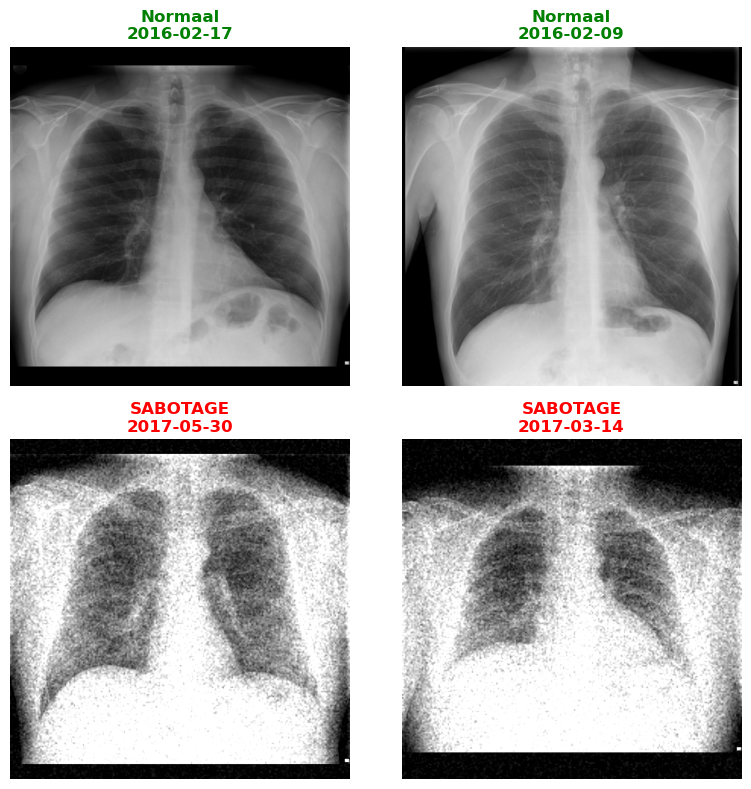

In [71]:
import matplotlib.pyplot as plt
import os
from PIL import Image

print(" Controleren hoe de fysieke sabotage eruit ziet...")

try:
    # We halen de referentie-instellingen uit de pipeline
    split_idx = int(len(df_meta) * CONFIG["drift_start_percentage"])
    
    # Filter op bestanden die echt bestaan in de map om crashes te voorkomen
    def check_exists(row):
        img_name = str(row['ImageID']).replace('.png', '').replace('.jpg', '') + '.png'
        return os.path.exists(os.path.join(IMG_DIR, img_name))
    
    df_norm_bestaand = df_meta[df_meta['StudyDate_DICOM'] < df_meta.iloc[split_idx]['StudyDate_DICOM']][df_meta.apply(check_exists, axis=1)]
    df_sab_bestaand = df_meta[df_meta['StudyDate_DICOM'] >= df_meta.iloc[split_idx]['StudyDate_DICOM']][df_meta.apply(check_exists, axis=1)]

    if len(df_norm_bestaand) >= 2 and len(df_sab_bestaand) >= 2:
        fig_img, axes = plt.subplots(2, 2, figsize=(8, 8))
        
        # Normale beelden (linksboven en rechtsboven)
        for ax, (_, row) in zip(axes[0], df_norm_bestaand.sample(2).iterrows()):
            pad = os.path.join(IMG_DIR, str(row['ImageID']).replace('.png', '').replace('.jpg', '') + '.png')
            ax.imshow(Image.open(pad), cmap='gray')
            ax.set_title(f"Normaal\n{row['StudyDate_DICOM'].date()}", color="green", fontweight="bold")
            ax.axis('off')
            
        # Gesaboteerde beelden (linksonder en rechtsonder)
        for ax, (_, row) in zip(axes[1], df_sab_bestaand.sample(2).iterrows()):
            pad = os.path.join(IMG_DIR, str(row['ImageID']).replace('.png', '').replace('.jpg', '') + '.png')
            ax.imshow(Image.open(pad), cmap='gray')
            status = "SABOTAGE" if CONFIG["fysieke_visuele_drift"] else "Normaal (Sabotage UIT)"
            kleur = "red" if CONFIG["fysieke_visuele_drift"] else "green"
            ax.set_title(f"{status}\n{row['StudyDate_DICOM'].date()}", color=kleur, fontweight="bold")
            ax.axis('off')

        plt.tight_layout()
        display(fig_img)
        plt.close() 
    else:
        print(" -> Niet genoeg verwerkte beelden gevonden in IMG_DIR om te laten zien.")
except Exception as e:
    print(f"Kon de controleplaatjes niet inladen: {e}")